### Problem 1:

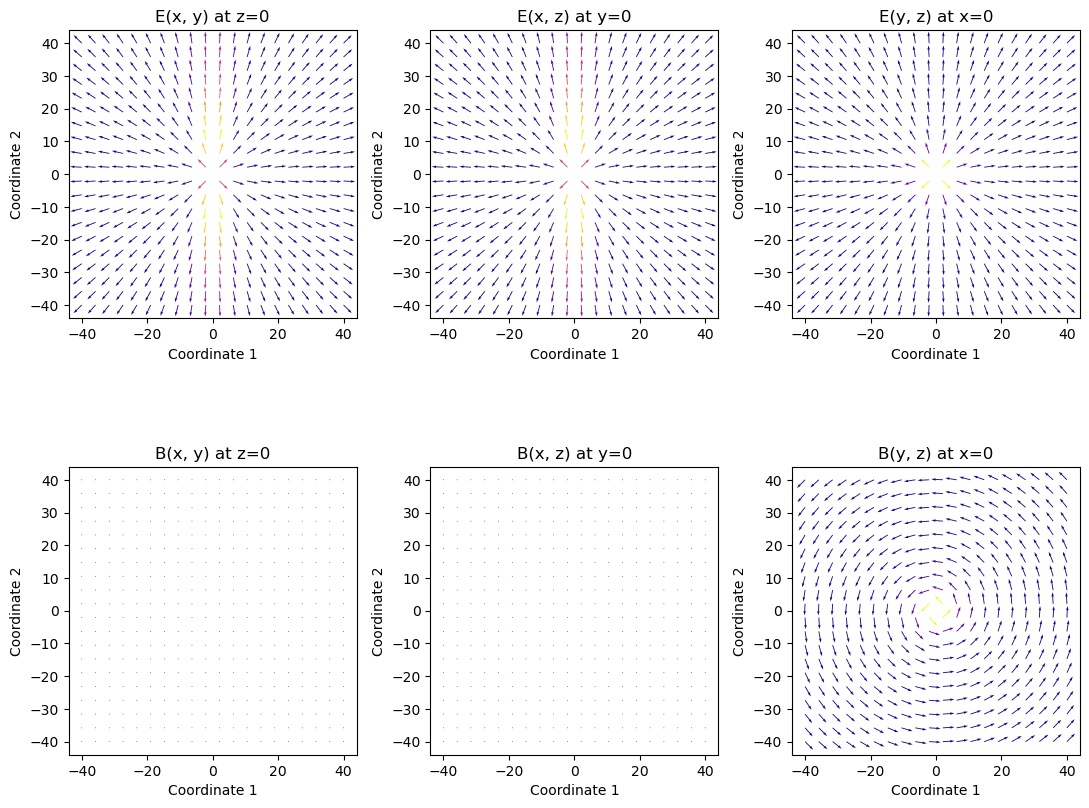

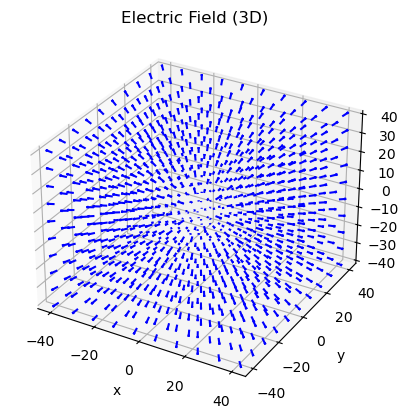

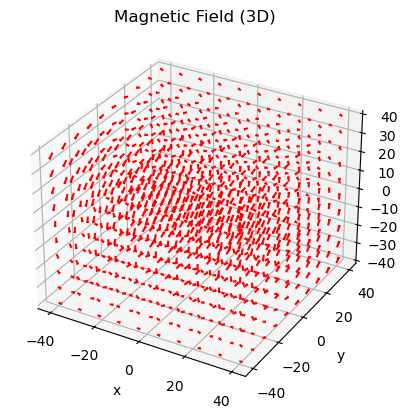

In [26]:
import numpy as np
import matplotlib.pyplot as plt

t=0
c=1.0
beta=0.99
charge=1.0
gamma=1/np.sqrt(1-beta**2)

npts=20
coords=np.linspace(-40,40, npts)
X,Y= np.meshgrid(coords,coords)
Xz,Z=np.meshgrid(coords, coords)
Yz,Zz=np.meshgrid(coords,coords)

def compute_fields(x,y,z_plane=0):
    r_eff=np.sqrt((gamma*(x- beta* c*t))**2+y**2 +z_plane**2)
    Ex=charge*gamma*(x-beta*c*t)/(r_eff**3)
    Ey=charge*gamma *y/(r_eff**3)
    Ez= charge*gamma*z_plane/(r_eff**3)
    Bx=np.zeros_like(Ex)
    By=-charge * gamma* beta*z_plane/(r_eff**3)
    Bz=charge*gamma* beta*y/(r_eff**3)
    return Ex,Ey,Ez,Bx,By,Bz

Ex_xy,Ey_xy,Ez_xy,Bx_xy,By_xy,Bz_xy=compute_fields(X,Y,0)
Ex_xz, Ey_xz, Ez_xz, Bx_xz, By_xz, Bz_xz = compute_fields(Xz, 0, Z)
Ex_yz, Ey_yz, Ez_yz, Bx_yz, By_yz, Bz_yz = compute_fields(0, Yz, Zz)


def normalize_field(Ex, Ey):              # Nomlalization: 
    mag=np.hypot(Ex, Ey)
    mag[mag==0]=1
    return Ex/mag, Ey/mag, mag


Exn_xy,Eyn_xy,Emag_xy =normalize_field(Ex_xy, Ey_xy)
Exn_xz,Ezn_xz,Emag_xz =normalize_field(Ex_xz, Ez_xz)
Eyn_yz,Ezn_yz,Emag_yz =normalize_field(Ey_yz, Ez_yz)
Bxn_xy,Byn_xy,Bmag_xy =normalize_field(Bx_xy, By_xy)
Bxn_xz,Bzn_xz,Bmag_xz =normalize_field(Bx_xz, Bz_xz)
Byn_yz ,Bzn_yz,Bmag_yz=normalize_field(By_yz, Bz_yz)

fig, ax = plt.subplots(2, 3, figsize=(11, 9))

ax[0, 0].quiver(X, Y, Exn_xy, Eyn_xy, Emag_xy, cmap='plasma', scale=25)
ax[0, 0].set_title("E(x, y) at z=0")

ax[0, 1].quiver(Xz, Z, Exn_xz, Ezn_xz, Emag_xz, cmap='plasma', scale=25)
ax[0, 1].set_title("E(x, z) at y=0")

ax[0, 2].quiver(Yz, Zz, Eyn_yz, Ezn_yz, Emag_yz, cmap='plasma', scale=25)
ax[0, 2].set_title("E(y, z) at x=0")

ax[1, 0].quiver(X, Y, Bxn_xy, Byn_xy, Bmag_xy, cmap='plasma', scale=25)
ax[1, 0].set_title("B(x, y) at z=0")

ax[1, 1].quiver(Xz, Z, Bxn_xz, Bzn_xz, Bmag_xz, cmap='plasma', scale=25)
ax[1, 1].set_title("B(x, z) at y=0")

ax[1, 2].quiver(Yz, Zz, Byn_yz, Bzn_yz, Bmag_yz, cmap='plasma', scale=25)
ax[1, 2].set_title("B(y, z) at x=0")

for a in ax.flat:
    a.set_aspect('equal')
    a.set_xlabel('Coordinate 1')
    a.set_ylabel('Coordinate 2')

plt.tight_layout()
plt.show()

x3,y3,z3=np.meshgrid(np.linspace(-40, 40, 10),
                     np.linspace(-40, 40, 10),
                    np.linspace(-40, 40, 10))

r3 =np.sqrt((gamma * (x3 - beta * c* t))**2 + y3**2 + z3**2)
Ex3= charge*gamma*(x3 - beta * c* t) / (r3**3)
Ey3= charge* gamma* y3 / (r3**3)
Ez3= charge*gamma * z3 / (r3**3)
Bx3= np.zeros_like(Ex3)
By3= -charge* gamma * beta * z3 / (r3**3)
Bz3= charge *gamma*beta * y3 / (r3**3)

figE = plt.figure()
axE = figE.add_subplot(projection='3d')
axE.quiver(x3, y3, z3, Ex3, Ey3, Ez3, length=3, normalize=True, color='blue')
axE.set_title("Electric Field (3D)")
axE.set_xlabel("x")
axE.set_ylabel("y")
axE.set_zlabel("z")

figB = plt.figure()
axB = figB.add_subplot(projection='3d')
axB.quiver(x3, y3, z3, Bx3, By3, Bz3, length=3, normalize=True, color='red')
axB.set_title("Magnetic Field (3D)")
axB.set_xlabel("x")
axB.set_ylabel("y")
axB.set_zlabel("z")

plt.show()


### Problem 2

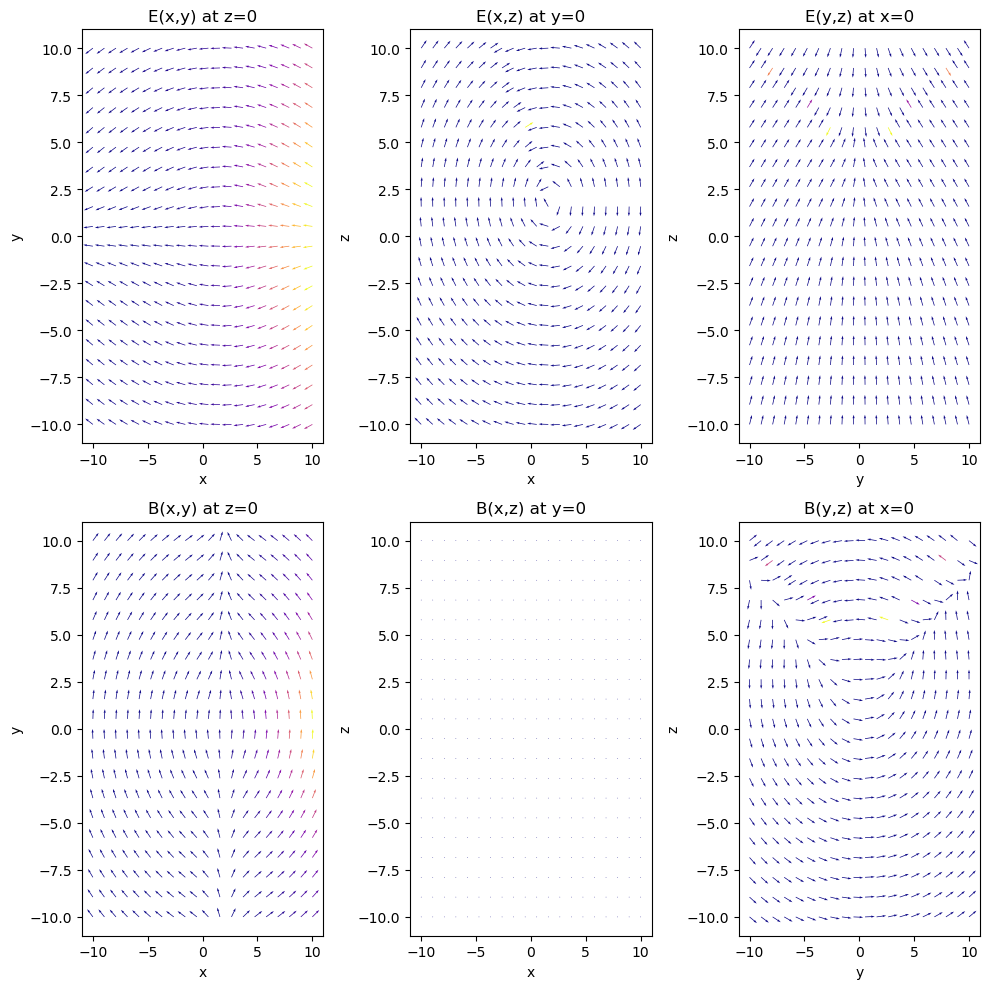

<Figure size 1000x1000 with 0 Axes>

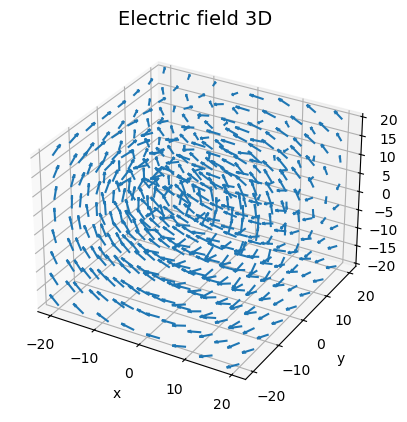

Text(0.5, 0, 'z')

<Figure size 1000x1000 with 0 Axes>

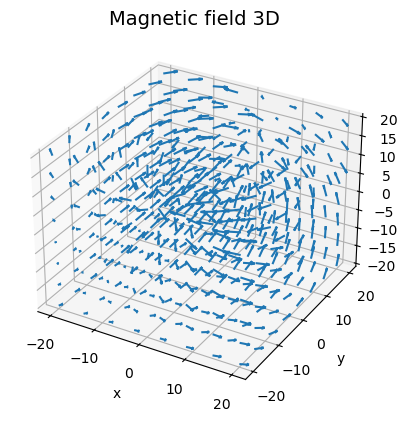

In [58]:
import numpy as np
import matplotlib.pyplot as plt

q=1
c=1
t_ret=2
beta=0.99
a0=0.9
def r_p(t):
    return np.array([beta*c*t,0,0.5*a0*t**2])

def v_p(t):
    return np.array([beta*c+0*t,0,a0*t])

def a_p(t):
    return np.array([a0,0,0])

def E_func(r_o):
    rp=r_p(t_ret);vp=v_p(t_ret);ap=a_p(t_ret)
    Rv=r_o-rp
    R=np.linalg.norm(Rv)
    n=Rv/R
    mpt=vp/c
    npe=ap/c
    kap=1.0-np.dot(n,mpt)
    numer=np.cross(n,np.cross(n-mpt,npe))
    E_rad=numer/((kap**3)*R)
    return E_rad

def B_func(r_o):
    E=E_func(r_o)
    rp=r_p(t_ret)
    Rv=r_o-rp
    n=Rv/(np.linalg.norm(Rv))
    B_rad=np.cross(n,E)
    return B_rad

nx=ny=nz=20
x=np.linspace(-10,10,20)
y=np.linspace(-10,10,20)
z=np.linspace(-10,10,20)
X,Y=np.meshgrid(x,y)

Ex1=np.zeros_like(X)
Ey1=np.zeros_like(X)
Ez1=np.zeros_like(X)
Bx1=np.zeros_like(X)
By1=np.zeros_like(X)
Bz1=np.zeros_like(X)
Ex2=np.zeros_like(X)
Ey2=np.zeros_like(X)
Ez2=np.zeros_like(X)
Bx2=np.zeros_like(X)
By2=np.zeros_like(X)
Bz2=np.zeros_like(X)

for j in range(ny):
    for i in range(nx):
        r_o=np.array([X[j,i],Y[j,i],0])
        E1=E_func(r_o)
        Ex1[j,i],Ey1[j,i]=E1[0],E1[1]

for j in range(ny):
    for i in range(nx):
        r_o=np.array([X[j,i],0,Y[j,i]])
        E2=E_func(r_o)
        Ex2[j,i],Ez1[j,i]=E2[0],E2[2]

for j in range(ny):
    for i in range(nx):
        r_o=np.array([0,X[j,i],Y[j,i]])
        E3=E_func(r_o)
        Ey2[j,i],Ez2[j,i]=E3[1],E3[2]


for j in range(ny):
    for i in range(nx):
        r_o=np.array([X[j,i],Y[j,i],0])
        B1=B_func(r_o)
        Bx1[j,i],By1[j,i]=B1[0],B1[1]

for j in range(ny):
    for i in range(nx):
        r_o=np.array([X[j,i],0,Y[j,i]])
        B2=B_func(r_o)
        Bx2[j,i],Bz1[j,i]=B2[0],B2[2]

for j in range(ny):
    for i in range(nx):
        r_o=np.array([0,X[j,i],Y[j,i]])
        B3=B_func(r_o)
        By2[j,i],Bz2[j,i]=B3[1],B3[2]


fig,ax=plt.subplots(2,3,figsize=(10,10))
mag1=np.hypot(Ex1,Ey1)
mag1[mag1==0.0]=1.0
ax[0,0].quiver(X,Y,Ex1/mag1,Ey1/mag1,mag1,cmap='plasma',scale=25)
ax[0,0].set_title("E(x,y) at z=0")
ax[0,0].set_xlabel("x") 
ax[0,0].set_ylabel("y")
mag2=np.hypot(Ex2,Ez1)
mag2[mag2==0.0]=1.0
ax[0,1].quiver(X,Y,Ex2/mag2,Ez1/mag2,mag2,cmap='plasma',scale=25)
ax[0,1].set_title("E(x,z) at y=0")
ax[0,1].set_xlabel("x") 
ax[0,1].set_ylabel("z")
mag3=np.hypot(Ey2,Ez2)
mag3[mag3==0.0]=1.0
ax[0,2].quiver(X,Y,Ey2/mag3,Ez2/mag3,mag3,cmap='plasma',scale=25)
ax[0,2].set_title("E(y,z) at x=0")
ax[0,2].set_xlabel("y") 
ax[0,2].set_ylabel("z")
mag4=np.hypot(Bx1,By1)
mag4[mag4==0.0]=1.0
ax[1,0].quiver(X,Y,Bx1/mag4,By1/mag4,mag4,cmap='plasma',scale=25)
ax[1,0].set_title("B(x,y) at z=0")
ax[1,0].set_xlabel("x") 
ax[1,0].set_ylabel("y")
mag5=np.hypot(Bx2,Bz1)
mag5[mag5==0.0]=1.0
ax[1,1].quiver(X,Y,Bx2/mag5,Bz1/mag5,mag5,cmap='plasma',scale=25)
ax[1,1].set_title("B(x,z) at y=0")
ax[1,1].set_xlabel("x") 
ax[1,1].set_ylabel("z")
mag6=np.hypot(By2,Bz2)
mag6[mag6==0.0]=1.0
ax[1,2].quiver(X,Y,By2/mag6,Bz2/mag6,mag6,cmap='plasma',scale=25)
ax[1,2].set_title("B(y,z) at x=0")
ax[1,2].set_xlabel("y") 
ax[1,2].set_ylabel("z")
plt.tight_layout()
plt.show()

#For the 3d plotting
Xd,Yd,Zd=np.meshgrid(np.linspace(-20,20,8),np.linspace(-20,20,8),np.linspace(-20,20,8))
Exd=np.zeros_like(Xd)
Eyd=np.zeros_like(Yd)
Ezd=np.zeros_like(Zd)
Bxd=np.zeros_like(Xd)
Byd=np.zeros_like(Yd)
Bzd=np.zeros_like(Zd)
for j in range(8):
    for i in range(8):
      for k in range (8):
        r_o=np.array([Xd[j,i,k],Yd[j,i,k],Zd[j,i,k]])
        Ed=E_func(r_o)
        Exd[j,i,k],Eyd[j,i,k],Ezd[j,i,k]=Ed[0],Ed[1],Ed[2]
        Bd=B_func(r_o)
        Bxd[j,i,k],Byd[j,i,k],Bzd[j,i,k]=Bd[0],Bd[1],Bd[2]

fig=plt.figure(figsize=(10,10))
ax=plt.figure().add_subplot(projection='3d')
ax.quiver(Xd,Yd,Zd,Exd,Eyd,Ezd,length=3,normalize=True)
ax.set_title("Electric field 3D",fontsize=14)
ax.set_xlabel("x"); ax.set_ylabel("y");ax.set_zlabel("z")
plt.show()
fig=plt.figure(figsize=(10,10))
ax=plt.figure().add_subplot(projection='3d')
ax.quiver(Xd,Yd,Zd,Bxd,Byd,Bzd,length=3,normalize=True)
ax.set_title("Magnetic field 3D",fontsize=14)
ax.set_xlabel("x"); ax.set_ylabel("y");ax.set_zlabel("z")


### Problem 3

#### Parallel Radiation 

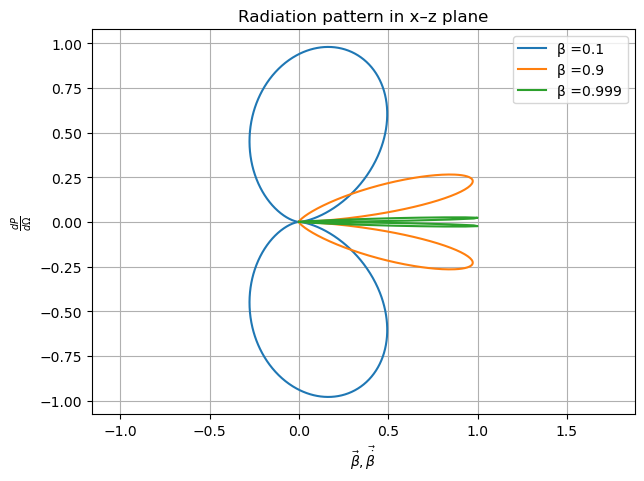

'Here i normalized it to see the pattern for v=0.1c,0.9c and 0.99c. But the origin pattern can be obtained if we through the I_max\n  term but then the problem for 0.99c the radiation is very strong that we cant see the radiation for 0.1c in the same plot.\n  So below i plot for some other values of velocity to compare.'

In [10]:
import numpy as np
import matplotlib.pyplot as plt

betas=[0.1,0.9,0.999]
theta=np.linspace(0,np.pi,800)

def radiation_profile(theta,beta):
    return np.sin(theta)**2/(1-beta*np.cos(theta))**5

plt.figure(figsize=(7, 5))

for beta in betas:
    I=radiation_profile(theta,beta)
    I/=I.max()
    r=I                            
    x=r*np.sin(theta)          
    z=r*np.cos(theta)           
    plt.plot(z,x,label=f'β ={beta}')
    plt.plot(z,-x,color=plt.gca().lines[-1].get_color()) 

plt.xlabel(r'$\vec{\beta},\vec{\dot{\beta}}$')
plt.ylabel(r'$\frac{dP}{d\Omega}$')
plt.title('Radiation pattern in x–z plane')
plt.legend()
plt.axis('equal')
plt.grid(True)

plt.show()

'''Here i normalized it to see the pattern for v=0.1c,0.9c and 0.99c. But the origin pattern can be obtained if we through the I_max
  term but then the problem for 0.99c the radiation is very strong that we cant see the radiation for 0.1c in the same plot.
  So below i plot for some other values of velocity to compare.'''

#### In these plot dP/dOmega is in unit of (mu_0*q^2*a^2)/(16pi^2*c) where acceleration a is different for parallel and perpendicular cases.

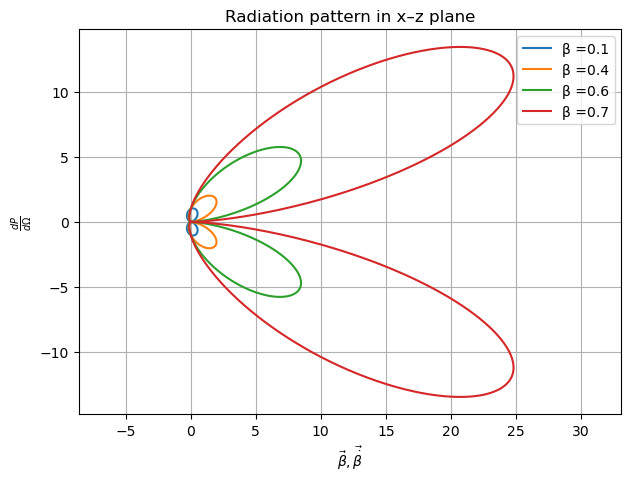

In [10]:
import numpy as np
import matplotlib.pyplot as plt

betas=[0.1,0.4,0.6,0.7]
theta=np.linspace(0,np.pi,800)

def radiation(theta,beta):
    return np.sin(theta)**2/(1-beta*np.cos(theta))**5

plt.figure(figsize=(7, 5))

for beta in betas:
    I=radiation(theta,beta)
    #I/=I.max()
    r=I                            
    x=r*np.sin(theta)          
    z=r*np.cos(theta)           
    plt.plot(z,x,label=f'β ={beta}')
    plt.plot(z,-x,color=plt.gca().lines[-1].get_color()) 


plt.xlabel(r'$\vec{\beta} , \vec{\dot{\beta}}$')
plt.ylabel(r'$\frac{dP}{d\Omega}$')
plt.title('Radiation pattern in x–z plane')
plt.legend()
plt.axis('equal')
plt.grid(True)

plt.show()


#### Perpendicular Radiation:

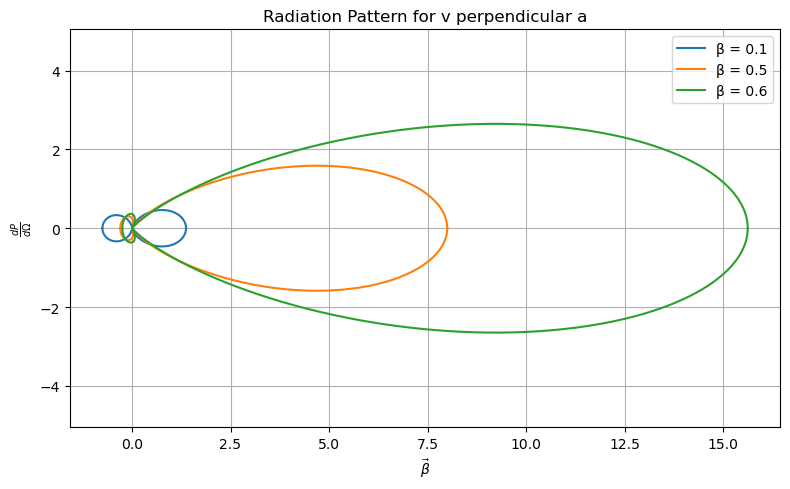

In [31]:
import numpy as np
import matplotlib.pyplot as plt

betas=[0.1,0.5,0.6]
theta=np.linspace(0,np.pi,1000)
phi=0  


def dPdw(theta,beta,phi):
    num=(1-beta*np.cos(theta))**2-(1-beta**2)*(np.sin(theta)**2)*(np.cos(phi)**2)
    y=(1-beta*np.cos(theta))**5
    return num/y

plt.figure(figsize=(8, 5))
for beta in betas:
    I=dPdw(theta,beta,phi)    
    I=np.clip(I,0,3e3)
    
    x=I*np.sin(theta)
    z=I*np.cos(theta)
    
    plt.plot(z,x,label=f'β = {beta}')
    plt.plot(z,-x,color=plt.gca().lines[-1].get_color()) 

plt.xlabel(r'$\vec{\beta}$')
plt.ylabel(r'$\frac{dP}{d\Omega}$')
plt.title('Radiation Pattern for v perpendicular a')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Same as previous i plot for velocity 0.1c,0.5c,0.6c to compare the result.

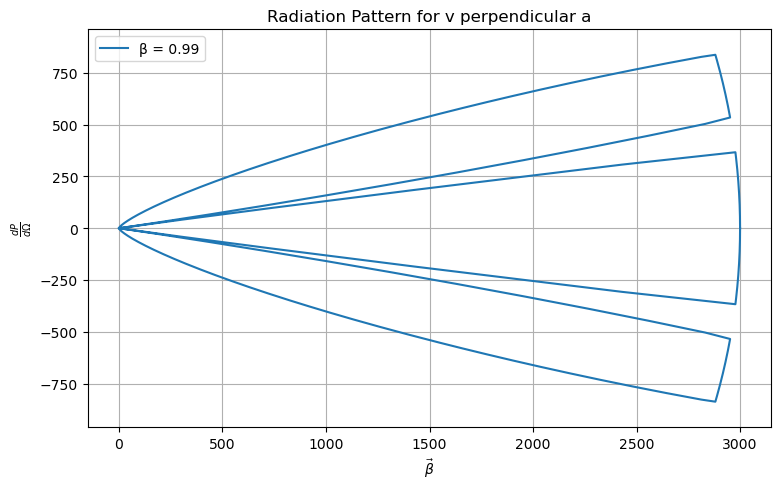

In [36]:
import numpy as np
import matplotlib.pyplot as plt

betas=[0.99]
theta=np.linspace(0,np.pi,1000)
phi=0  


def dPdw(theta,beta,phi):
    num=(1-beta*np.cos(theta))**2-(1-beta**2)*(np.sin(theta)**2)*(np.cos(phi)**2)
    y=(1-beta*np.cos(theta))**5
    return num/y

plt.figure(figsize=(8, 5))
for beta in betas:
    I=dPdw(theta,beta,phi)    
    I=np.clip(I,0,3e3)
    
    x=I*np.sin(theta)
    z=I*np.cos(theta)
    
    plt.plot(z,x,label=f'β = {beta}')
    plt.plot(z,-x,color=plt.gca().lines[-1].get_color()) 

plt.xlabel(r'$\vec{\beta}$')
plt.ylabel(r'$\frac{dP}{d\Omega}$')
plt.title('Radiation Pattern for v perpendicular a')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Problem 5

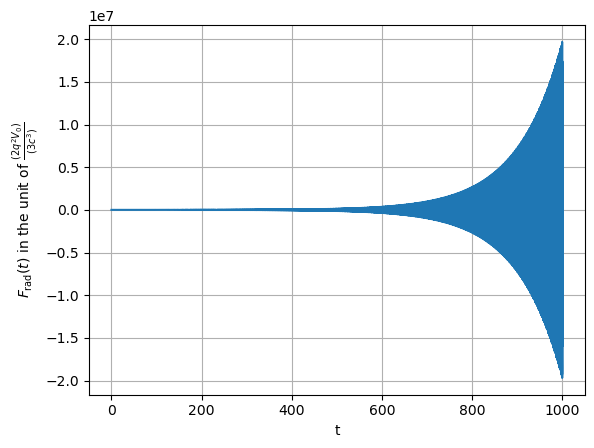

In [58]:
import numpy as np
import matplotlib.pyplot as plt

t=np.linspace(0,1000,10000)
y=np.exp(t/100)*((3/5)*np.cos(30*t)-(1/10000 - 900)*np.sin(30*t))

plt.plot(t,y)
plt.xlabel('t')
plt.ylabel(r'$F_{\mathrm{rad}}(t)$ in the unit of $\frac{(2q^2V_0)}{(3c^3)}$')
plt.grid(True)
plt.show()


### Problem 6

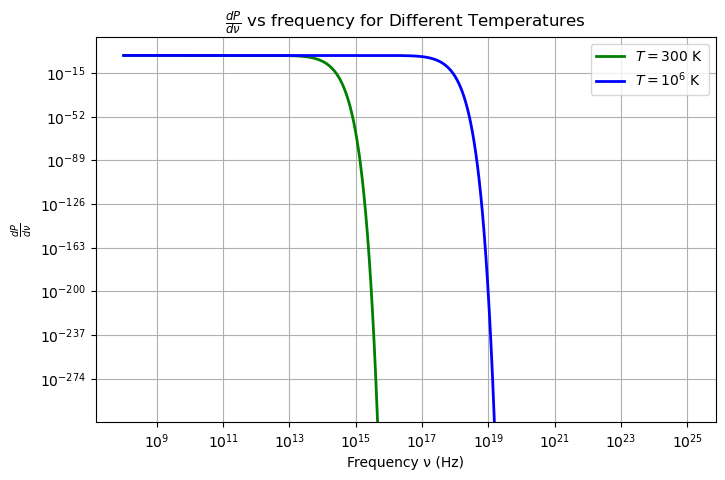

In [7]:
import numpy as np
import matplotlib.pyplot as plt

h=6.62607015e-34
kB=1.380649e-23
nu=np.logspace(8,25,1000) 

def y_vs_nu(nu,T):
    x=(h*nu)/(kB*T)
    y=(1/np.sqrt(T))*(2.2*x*np.exp(-x)+2.2*np.exp(-x)+0.6*x**2*np.exp(-x))
    return y

temps=[300, 1000000]
colors=['green','blue']
labels=[r"$T=300\ \mathrm{K}$",r"$T=10^6\ \mathrm{K}$"]

plt.figure(figsize=(8,5))
for T,c,label in zip(temps,colors,labels):
    y=y_vs_nu(nu,T)
    plt.loglog(nu,y/np.max(y),label=label,color=c,lw=2)  

plt.xlabel("Frequency ν (Hz)")
plt.ylabel(r'$\frac{dP}{d\nu}$')
plt.title(r'$\frac{dP}{d\nu}$ vs frequency for Different Temperatures')
plt.grid()
plt.legend()
plt.show()
